In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("ai_copilot_interactions.csv")

EDA

In [8]:
df.shape

(1200, 25)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   1200 non-null   str    
 1   session_id                1200 non-null   str    
 2   event_date                1200 non-null   str    
 3   signup_date               1200 non-null   str    
 4   plan                      1200 non-null   str    
 5   country                   1200 non-null   str    
 6   device                    1200 non-null   str    
 7   company_size              1200 non-null   str    
 8   feature_used              1200 non-null   str    
 9   prompt_category           1200 non-null   str    
 10  ai_model                  1200 non-null   str    
 11  prompt_length_words       1200 non-null   int64  
 12  tokens_used               1200 non-null   int64  
 13  latency_seconds           1200 non-null   float64
 14  session_duration_mi

In [11]:
df.describe()

,prompt_length_words,tokens_used,latency_seconds,session_duration_minutes,prompts_in_session,rating,revenue_usd
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,64.654167,388.398333,2.676242,9.422000,2.356667,3.653333,42.873367
std,44.568092,154.429364,1.658341,5.800227,0.752725,1.301115,107.324006
min,7.000000,87.000000,0.770000,3.000000,2.000000,1.000000,0.000000
25%,35.000000,262.750000,1.590000,5.400000,2.000000,3.000000,0.000000
50%,54.000000,389.000000,2.250000,7.500000,2.000000,4.000000,0.000000
75%,80.250000,503.000000,3.070000,12.100000,2.000000,5.000000,31.150000
max,450.000000,973.000000,10.360000,35.900000,6.000000,5.000000,489.820000


In [4]:
df['event_date'] = pd.to_datetime(df['event_date'])
df['signup_date'] = pd.to_datetime(df['signup_date'])

In [13]:
df.isnull().sum()

user_id                     0
session_id                  0
event_date                  0
signup_date                 0
plan                        0
country                     0
device                      0
company_size                0
feature_used                0
prompt_category             0
ai_model                    0
prompt_length_words         0
tokens_used                 0
latency_seconds             0
session_duration_minutes    0
prompts_in_session          0
regenerated_response        0
copied_response             0
rating                      0
feedback                    0
converted_to_paid           0
revenue_usd                 0
retained_7d                 0
error_flag                  0
response_success            0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

User & Product Overview

In [15]:
df["user_id"].nunique()

250

In [16]:
df["session_id"].nunique()

543

In [4]:
df["plan"].value_counts()

plan
Free          686
Pro           402
Enterprise    112
Name: count, dtype: int64

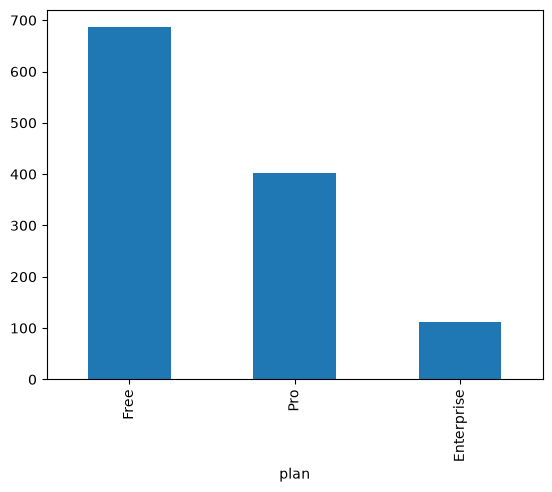

In [5]:
df["plan"].value_counts().plot(kind="bar")
plt.show()

In [6]:
df["country"].value_counts()

country
India             321
United States     285
United Kingdom    155
Australia         132
Germany           118
Canada             82
Singapore          57
Brazil             50
Name: count, dtype: int64

In [7]:
df["device"].value_counts()

device
Desktop    648
Mobile     412
Tablet     140
Name: count, dtype: int64

Revenue Analysis

In [8]:
df["revenue_usd"].sum()

np.float64(51448.04)

In [ ]:
df.groupby("ai_model")["revenue_usd"].sum().sort_values(ascending=False)

ai_model
GPT-4.1        25656.29
GPT-4o         17698.85
GPT-4o-mini     8092.90
Name: revenue_usd, dtype: float64

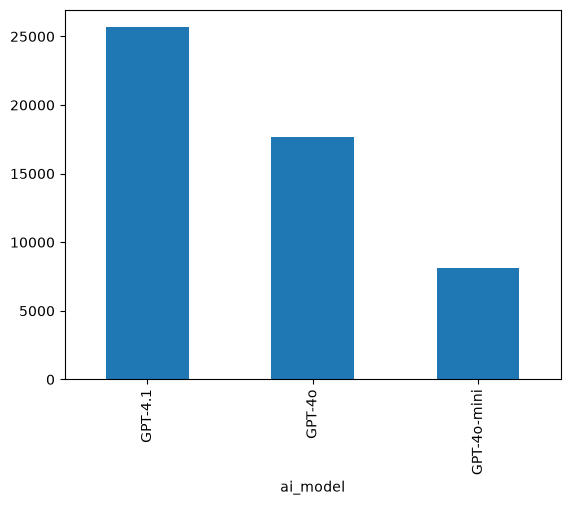

In [10]:
df.groupby("ai_model")["revenue_usd"].sum().plot(kind="bar")
plt.show()

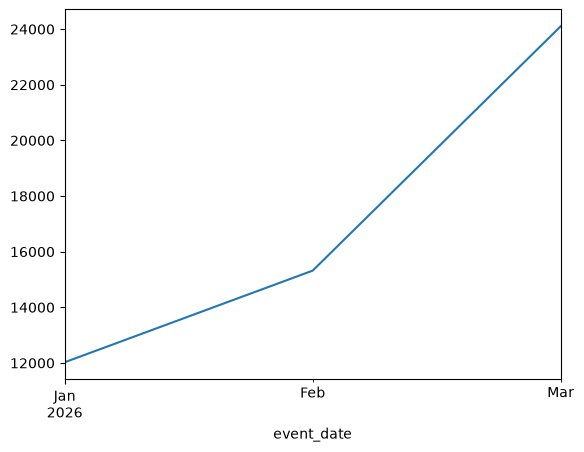

In [6]:
monthly_rev = df.groupby(
    df['event_date'].dt.to_period('M')
)['revenue_usd'].sum()

monthly_rev.plot(kind='line')
plt.show()

In [ ]:
df.groupby("country")["revenue_usd"].sum().sort_values(ascending=False)

country
Australia         11840.22
India             11615.50
United States     10183.62
United Kingdom     8324.48
Germany            7558.76
Canada              743.22
Singapore           687.30
Brazil              494.94
Name: revenue_usd, dtype: float64

Retention Analysis

In [13]:
df["retained_7d"].value_counts(normalize=True)*100

retained_7d
Yes    52.5
No     47.5
Name: proportion, dtype: float64

In [14]:
pd.crosstab(
    df["feature_used"],
    df["retained_7d"],
    normalize="index"
)*100

retained_7d,No,Yes
feature_used,,
Chat,46.434494,53.565506
File Upload,50.000000,50.000000
Image Generation,48.412698,51.587302
Search,49.790795,50.209205
Voice,39.285714,60.714286


In [15]:
pd.crosstab(
    df["plan"],
    df["retained_7d"],
    normalize="index"
)*100

retained_7d,No,Yes
plan,,
Enterprise,0.000000,100.000000
Free,60.349854,39.650146
Pro,38.805970,61.194030


In [7]:
pd.crosstab(
    df["ai_model"],
    df["retained_7d"],
    normalize="index"
)*100

retained_7d,No,Yes
ai_model,,
GPT-4.1,37.121212,62.878788
GPT-4o,47.290640,52.709360
GPT-4o-mini,52.830189,47.169811


Conversion Analysis

In [16]:
df["converted_to_paid"].value_counts(normalize=True)*100

converted_to_paid
No     57.166667
Yes    42.833333
Name: proportion, dtype: float64

In [17]:
pd.crosstab(
    df["country"],
    df["converted_to_paid"],
    normalize="index"
)*100

converted_to_paid,No,Yes
country,,
Australia,63.636364,36.363636
Brazil,64.000000,36.000000
Canada,70.731707,29.268293
Germany,61.016949,38.983051
India,58.255452,41.744548
Singapore,57.894737,42.105263
United Kingdom,41.935484,58.064516
United States,54.385965,45.614035


In [18]:
pd.crosstab(
    df["feature_used"],
    df["converted_to_paid"],
    normalize="index"
)*100

converted_to_paid,No,Yes
feature_used,,
Chat,57.213930,42.786070
File Upload,60.795455,39.204545
Image Generation,54.761905,45.238095
Search,58.158996,41.841004
Voice,46.428571,53.571429


In [8]:
pd.crosstab(
    df["plan"],
    df["converted_to_paid"],
    normalize="index"
)*100

converted_to_paid,No,Yes
plan,,
Enterprise,0.0,100.0
Free,100.0,0.0
Pro,0.0,100.0


Product Performance

In [19]:
pd.crosstab(
    df["ai_model"],
    df["response_success"],
    normalize="index"
)*100

response_success,No,Yes
ai_model,,
GPT-4.1,7.954545,92.045455
GPT-4o,6.650246,93.349754
GPT-4o-mini,9.622642,90.377358


In [20]:
df.groupby("ai_model")["rating"].mean()

ai_model
GPT-4.1        3.867424
GPT-4o         3.714286
GPT-4o-mini    3.500000
Name: rating, dtype: float64

In [21]:
df.groupby("latency_seconds")["rating"].mean()

latency_seconds
0.77     4.000000
0.78     4.000000
0.80     4.000000
0.81     3.333333
0.82     3.000000
           ...   
9.16     3.000000
9.51     4.000000
9.54     2.000000
9.82     4.000000
10.36    3.000000
Name: rating, Length: 444, dtype: float64

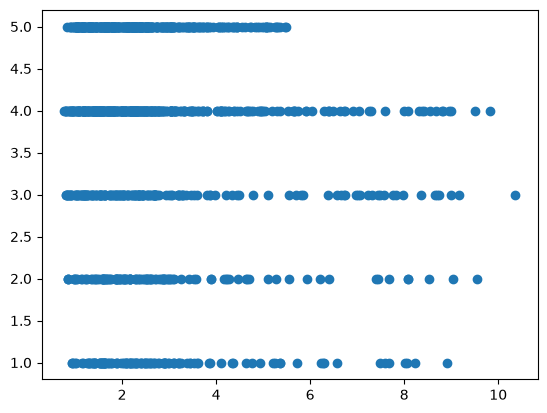

In [ ]:
plt.scatter(
    df["latency_seconds"],
    df["rating"])
plt.show()

Power User Analysis

In [ ]:
df.groupby("user_id")["revenue_usd"].sum().sort_values(ascending=False).head(10)

user_id
U0236    3918.56
U0092    3865.52
U0231    3861.20
U0095    3701.92
U0045    3566.88
U0133    3163.52
U0090    3098.72
U0175    2923.84
U0026    2844.64
U0209    2770.08
Name: revenue_usd, dtype: float64

In [ ]:
df.groupby("user_id")["tokens_used"].sum().sort_values(ascending=False).head(10)


user_id
U0045    4361
U0026    4237
U0175    4142
U0090    4094
U0097    3877
U0209    3868
U0061    3828
U0133    3815
U0220    3482
U0236    3392
Name: tokens_used, dtype: int64